# PCA-FiLM 30 vs. 50 PCs: Seed-Level Comparison

This notebook compares whether PCA-FiLM models conditioned on 50 PCs outperform PCA-FiLM models conditioned on 30 PCs across repeated training runs.

It uses cached predictions from `predict_morphology_test.py` when available, and can also read validation metrics from training output folders. The key comparison is paired by seed: `delta = nW1_30pc - nW1_50pc`. Positive delta means the 50-PC model has lower error.

In [8]:
from __future__ import annotations

from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance, ttest_rel, wilcoxon, binomtest

sns.set_theme(style="whitegrid", context="talk")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PREDICTION_ROOTS = [PROJECT_ROOT / "outputs" / "test_predictions"]
METRIC_ROOTS = [
    PROJECT_ROOT / "outputs" / "morphology_repeats",
    PROJECT_ROOT / "outputs" / "morphology",
    PROJECT_ROOT / "outputs" / "test_predictions" / "artifacts",
    PROJECT_ROOT / "outputs" / "validation_model_comparison" / "artifacts",
]
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "pca_film_30_vs_50_stats"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PC_DIMS = [30, 50]
MODEL_VARIANT = "pca_film"
RNG_SEED = 7

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: /Users/hannesneumann/Repositories/conditional-flow-matching-seminar
Output dir:   /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/pca_film_30_vs_50_stats


## Load Test/OOD Metrics From Cached Predictions

In [9]:
def mean_normalized_w1(y_real: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    w1 = np.array([
        wasserstein_distance(y_real[:, i], y_pred[:, i])
        for i in range(y_real.shape[1])
    ])
    real_std = y_real.std(axis=0)
    return float(np.mean(w1 / np.maximum(real_std, eps)))


def infer_seed_and_cdim_from_name(path: Path) -> tuple[int | None, int | None]:
    text = str(path)
    seed_match = re.search(r"seed[-_ ]?(\d+)", text)
    cdim_match = re.search(r"(\d+)pc", text.lower())
    seed = int(seed_match.group(1)) if seed_match else None
    c_dim = int(cdim_match.group(1)) if cdim_match else None
    return seed, c_dim


def load_prediction_metric(prediction_path: Path) -> dict | None:
    metadata_path = prediction_path.parent / "metadata.json"
    metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
    cfg = metadata.get("config", {})
    spec = metadata.get("spec", {})

    model_variant = cfg.get("model_variant") or spec.get("model_variant")
    c_dim = cfg.get("c_dim") or spec.get("c_dim")
    # metadata['seed'] is the prediction/sampling seed. For paired model comparison
    # we need the training seed from the saved training config.
    seed = cfg.get("seed") or spec.get("seed") or metadata.get("seed")
    if seed is None or c_dim is None:
        inferred_seed, inferred_cdim = infer_seed_and_cdim_from_name(prediction_path)
        seed = seed if seed is not None else inferred_seed
        c_dim = c_dim if c_dim is not None else inferred_cdim

    if model_variant != MODEL_VARIANT or c_dim not in PC_DIMS:
        return None

    arr = np.load(prediction_path, allow_pickle=True)
    score = mean_normalized_w1(
        arr["y_real"].astype(np.float64),
        arr["y_pred"].astype(np.float64),
    )
    return {
        "split": "test_ood",
        "seed": int(seed),
        "c_dim": int(c_dim),
        "mean_normalized_w1": score,
        "run_name": metadata.get("model_name", prediction_path.parent.name),
        "path": str(prediction_path),
    }


test_rows = []
for root in PREDICTION_ROOTS:
    for prediction_path in sorted(root.glob("*/predictions.npz")):
        row = load_prediction_metric(prediction_path)
        if row is not None:
            test_rows.append(row)

test_df = pd.DataFrame(test_rows)
if test_df.empty:
    print("No cached PCA-FiLM test predictions found yet.")
else:
    test_df = test_df.sort_values(["c_dim", "seed", "run_name"])
    display(test_df)
    test_df.to_csv(OUTPUT_DIR / "test_ood_run_metrics.csv", index=False)

,split,seed,c_dim,mean_normalized_w1,run_name,path
0,test_ood,42,30,0.099598,30pc_film,/Users/hannesneumann/Repositories/conditional-...
1,test_ood,43,30,0.090776,30pc_film_seed_43,/Users/hannesneumann/Repositories/conditional-...
2,test_ood,44,30,0.099967,30pc_film_seed_44,/Users/hannesneumann/Repositories/conditional-...
3,test_ood,42,50,0.097058,50pc_film_model,/Users/hannesneumann/Repositories/conditional-...
4,test_ood,43,50,0.092745,50pc_film_seed_43,/Users/hannesneumann/Repositories/conditional-...
5,test_ood,44,50,0.095870,50pc_film_seed_44,/Users/hannesneumann/Repositories/conditional-...


## Load Validation Metrics From Training Runs

In [10]:
def metric_from_validation_json(metrics: dict) -> float | None:
    value = metrics.get("mean_normalized_w1")
    if value is not None:
        return float(value)

    clusters = metrics.get("clusters", [])
    cluster_values = [c.get("mean_normalized_w1") for c in clusters]
    cluster_values = [float(v) for v in cluster_values if v is not None]
    if cluster_values:
        return float(np.mean(cluster_values))
    return None


def load_validation_metric(metrics_path: Path) -> dict | None:
    config_path = metrics_path.parent / "config.json"
    if not config_path.exists():
        return None
    cfg = json.loads(config_path.read_text())
    if cfg.get("model_variant") != MODEL_VARIANT or cfg.get("c_dim") not in PC_DIMS:
        return None

    metrics = json.loads(metrics_path.read_text())
    score = metric_from_validation_json(metrics)
    if score is None:
        return None

    return {
        "split": "validation",
        "seed": int(cfg["seed"]),
        "c_dim": int(cfg["c_dim"]),
        "mean_normalized_w1": score,
        "run_name": metrics_path.parent.name,
        "path": str(metrics_path),
    }


validation_rows = []
for root in METRIC_ROOTS:
    for metrics_path in sorted(root.glob("**/validation_cluster_metrics.json")):
        row = load_validation_metric(metrics_path)
        if row is not None:
            validation_rows.append(row)

validation_df = pd.DataFrame(validation_rows)
if validation_df.empty:
    print("No normalized validation metrics found.")
else:
    # Keep one row per split/seed/c_dim. Prefer morphology_repeats when duplicates exist.
    validation_df["priority"] = validation_df["path"].str.contains("morphology_repeats").map({True: 0, False: 1})
    validation_df = (
        validation_df
        .sort_values(["split", "seed", "c_dim", "priority", "path"])
        .drop_duplicates(["split", "seed", "c_dim"], keep="first")
        .drop(columns="priority")
        .sort_values(["c_dim", "seed"])
    )
    display(validation_df)
    validation_df.to_csv(OUTPUT_DIR / "validation_run_metrics.csv", index=False)

,split,seed,c_dim,mean_normalized_w1,run_name,path
4,validation,42,30,0.049240,vibrant-wood-24-vegt5jv9,/Users/hannesneumann/Repositories/conditional-...
0,validation,43,30,0.086177,pca-film-30pc-seed-43-jt7aseej,/Users/hannesneumann/Repositories/conditional-...
1,validation,44,30,0.092407,pca-film-30pc-seed-44-ja5s1g56,/Users/hannesneumann/Repositories/conditional-...
2,validation,43,50,0.084187,pca-film-50pc-seed-43-ilnqpck5,/Users/hannesneumann/Repositories/conditional-...
3,validation,44,50,0.091348,pca-film-50pc-seed-44-4r2s4ni6,/Users/hannesneumann/Repositories/conditional-...


## Paired Statistical Comparison

In [11]:
def paired_table(df: pd.DataFrame, split: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    part = df[df["split"] == split].copy()
    if part.empty:
        return pd.DataFrame()
    pivot = (
        part
        .pivot_table(index="seed", columns="c_dim", values="mean_normalized_w1", aggfunc="mean")
        .dropna(subset=PC_DIMS)
        .reset_index()
    )
    if pivot.empty:
        return pivot
    pivot["delta_30_minus_50"] = pivot[30] - pivot[50]
    pivot["winner"] = np.where(pivot["delta_30_minus_50"] > 0, "50 PCs", "30 PCs")
    return pivot


def bootstrap_ci(values: np.ndarray, n_boot: int = 20_000, seed: int = RNG_SEED) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    if len(values) == 0:
        return np.nan, np.nan
    means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]))


def paired_stats(pairs: pd.DataFrame) -> dict:
    if pairs.empty:
        return {"n_pairs": 0}
    d = pairs["delta_30_minus_50"].to_numpy(dtype=float)
    stats = {
        "n_pairs": int(len(d)),
        "mean_delta_30_minus_50": float(np.mean(d)),
        "median_delta_30_minus_50": float(np.median(d)),
        "std_delta": float(np.std(d, ddof=1)) if len(d) > 1 else np.nan,
        "fraction_50pc_better": float(np.mean(d > 0)),
    }
    lo, hi = bootstrap_ci(d)
    stats["bootstrap_mean_delta_ci_low"] = float(lo)
    stats["bootstrap_mean_delta_ci_high"] = float(hi)

    if len(d) >= 2:
        t_res = ttest_rel(pairs[30], pairs[50], alternative="greater")
        stats["paired_ttest_p_one_sided_30_gt_50"] = float(t_res.pvalue)
    else:
        stats["paired_ttest_p_one_sided_30_gt_50"] = np.nan

    if len(d) >= 2 and np.any(d != 0):
        try:
            w_res = wilcoxon(d, alternative="greater", zero_method="wilcox")
            stats["wilcoxon_p_one_sided_delta_gt_0"] = float(w_res.pvalue)
        except ValueError:
            stats["wilcoxon_p_one_sided_delta_gt_0"] = np.nan
    else:
        stats["wilcoxon_p_one_sided_delta_gt_0"] = np.nan

    n_positive = int(np.sum(d > 0))
    if len(d) > 0:
        stats["sign_test_p_one_sided_50pc_better"] = float(
            binomtest(n_positive, len(d), p=0.5, alternative="greater").pvalue
        )
    else:
        stats["sign_test_p_one_sided_50pc_better"] = np.nan
    return stats


all_metrics = pd.concat([test_df, validation_df], ignore_index=True)
all_metrics.to_csv(OUTPUT_DIR / "all_pca_film_30_50_metrics.csv", index=False)

pairs_by_split = {}
stats_rows = []
for split in sorted(all_metrics["split"].dropna().unique()):
    pairs = paired_table(all_metrics, split)
    pairs_by_split[split] = pairs
    if not pairs.empty:
        pairs.to_csv(OUTPUT_DIR / f"paired_{split}_metrics.csv", index=False)
    stats = paired_stats(pairs)
    stats["split"] = split
    stats_rows.append(stats)

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(OUTPUT_DIR / "paired_statistical_tests.csv", index=False)
display(stats_df)

for split, pairs in pairs_by_split.items():
    print("\n" + f"{split}: paired seeds")
    display(pairs)

,n_pairs,mean_delta_30_minus_50,median_delta_30_minus_50,std_delta,fraction_50pc_better,bootstrap_mean_delta_ci_low,bootstrap_mean_delta_ci_high,paired_ttest_p_one_sided_30_gt_50,wilcoxon_p_one_sided_delta_gt_0,sign_test_p_one_sided_50pc_better,split
0,3,0.001556,0.002540,0.003151,0.666667,-0.001970,0.004097,0.241283,0.25,0.50,test_ood
1,2,0.001525,0.001525,0.000658,1.000000,0.001059,0.001990,0.094277,0.25,0.25,validation



test_ood: paired seeds


c_dim,seed,30,50,delta_30_minus_50,winner
0,42,0.099598,0.097058,0.002540,50 PCs
1,43,0.090776,0.092745,-0.001970,30 PCs
2,44,0.099967,0.095870,0.004097,50 PCs



validation: paired seeds


c_dim,seed,30,50,delta_30_minus_50,winner
0,43,0.086177,0.084187,0.001990,50 PCs
1,44,0.092407,0.091348,0.001059,50 PCs


## Interpretation Helper

Positive `delta_30_minus_50` means the 50-PC model performed better for that seed. With only three paired seeds, p-values are usually not very powerful. For a seminar, the most honest report is often mean ± standard deviation plus the direction of the paired deltas.

In [12]:
def conclusion_sentence(stats_df: pd.DataFrame, split: str) -> str:
    row = stats_df[stats_df["split"] == split]
    if row.empty:
        return f"No paired {split} comparison available."
    r = row.iloc[0]
    n = int(r["n_pairs"])
    if n == 0:
        return f"No paired {split} comparison available."
    mean_delta = r["mean_delta_30_minus_50"]
    ci_low = r["bootstrap_mean_delta_ci_low"]
    ci_high = r["bootstrap_mean_delta_ci_high"]
    frac = r["fraction_50pc_better"]
    p = r["paired_ttest_p_one_sided_30_gt_50"]
    return (
        f"{split}: Across {n} paired seeds, mean nW1(30PC) - nW1(50PC) = "
        f"{mean_delta:+.4f} (bootstrap 95% CI {ci_low:+.4f} to {ci_high:+.4f}); "
        f"50PC wins in {frac:.0%} of seeds; one-sided paired t-test p={p:.3g}."
    )

for split in sorted(pairs_by_split):
    print(conclusion_sentence(stats_df, split))

test_ood: Across 3 paired seeds, mean nW1(30PC) - nW1(50PC) = +0.0016 (bootstrap 95% CI -0.0020 to +0.0041); 50PC wins in 67% of seeds; one-sided paired t-test p=0.241.
validation: Across 2 paired seeds, mean nW1(30PC) - nW1(50PC) = +0.0015 (bootstrap 95% CI +0.0011 to +0.0020); 50PC wins in 100% of seeds; one-sided paired t-test p=0.0943.


## Visualize Paired Runs

Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/pca_film_30_vs_50_stats/paired_30_vs_50_test_ood.png
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/pca_film_30_vs_50_stats/paired_30_vs_50_test_ood.svg


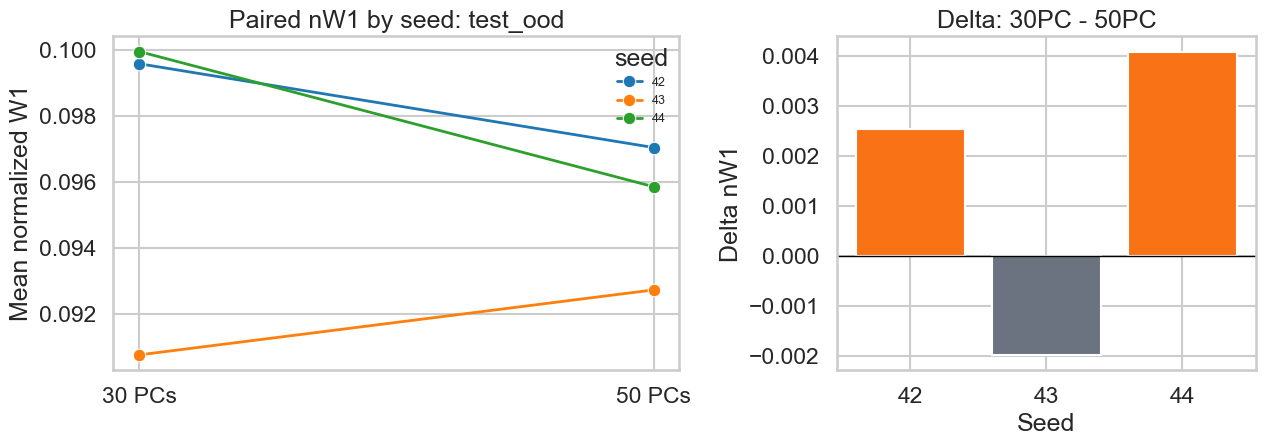

Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/pca_film_30_vs_50_stats/paired_30_vs_50_validation.png
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/pca_film_30_vs_50_stats/paired_30_vs_50_validation.svg


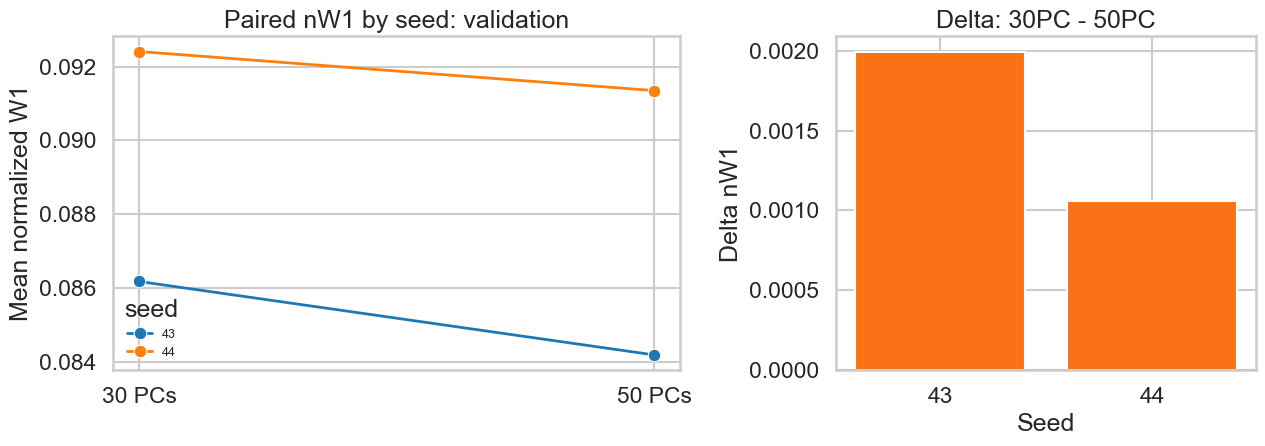

In [13]:
def plot_paired_split(pairs: pd.DataFrame, split: str) -> None:
    if pairs.empty:
        print(f"Skipping {split}: no paired rows")
        return
    long = pairs.melt(
        id_vars=["seed", "delta_30_minus_50", "winner"],
        value_vars=PC_DIMS,
        var_name="PCs",
        value_name="mean_normalized_w1",
    )
    long["PCs"] = long["PCs"].astype(str) + " PCs"

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.35, 1]})

    ax = axes[0]
    sns.lineplot(
        data=long,
        x="PCs",
        y="mean_normalized_w1",
        hue="seed",
        marker="o",
        linewidth=2,
        palette="tab10",
        ax=ax,
    )
    ax.set_title(f"Paired nW1 by seed: {split}")
    ax.set_xlabel("")
    ax.set_ylabel("Mean normalized W1")
    ax.legend(title="seed", frameon=False, fontsize=9)

    ax = axes[1]
    colors = ["#F97316" if d > 0 else "#6B7280" for d in pairs["delta_30_minus_50"]]
    ax.bar(pairs["seed"].astype(str), pairs["delta_30_minus_50"], color=colors)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Delta: 30PC - 50PC")
    ax.set_xlabel("Seed")
    ax.set_ylabel("Delta nW1")

    plt.tight_layout()
    for suffix in ["png", "svg"]:
        path = OUTPUT_DIR / f"paired_30_vs_50_{split}.{suffix}"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved {path}")
    plt.show()

for split, pairs in pairs_by_split.items():
    plot_paired_split(pairs, split)

## Optional: Missing Test Predictions for Repeat Runs

In [14]:
def trained_pca_film_runs() -> pd.DataFrame:
    rows = []
    for config_path in sorted((PROJECT_ROOT / "outputs").glob("**/config.json")):
        try:
            cfg = json.loads(config_path.read_text())
        except Exception:
            continue
        if cfg.get("model_variant") != MODEL_VARIANT or cfg.get("c_dim") not in PC_DIMS:
            continue
        checkpoint = config_path.parent / "model_ema.pt"
        if not checkpoint.exists():
            step_checkpoints = sorted((config_path.parent / "checkpoints").glob("model_ema_step_*.pt"))
            checkpoint = step_checkpoints[-1] if step_checkpoints else checkpoint
        y_stats = config_path.parent / "y_stats.pt"
        rows.append({
            "seed": cfg.get("seed"),
            "c_dim": cfg.get("c_dim"),
            "run_dir": str(config_path.parent),
            "checkpoint_exists": checkpoint.exists(),
            "checkpoint_path": str(checkpoint),
            "config_path": str(config_path),
            "y_stats_path": str(y_stats),
        })
    return pd.DataFrame(rows)

trained_runs = trained_pca_film_runs()
display(trained_runs.sort_values(["c_dim", "seed", "run_dir"]))

available_test_pairs = paired_table(test_df, "test_ood") if not test_df.empty else pd.DataFrame()
available_test_seeds = set(available_test_pairs["seed"]) if not available_test_pairs.empty else set()
print("Seeds with paired cached test predictions:", sorted(available_test_seeds))

missing_for_test = trained_runs[
    trained_runs["checkpoint_exists"]
    & ~trained_runs["seed"].isin(available_test_seeds)
].sort_values(["seed", "c_dim"])

if not missing_for_test.empty:
    print()
    print("Runs that are trained but do not yet have paired cached test predictions:")
    display(missing_for_test)
    specs = []
    for _, row in missing_for_test.iterrows():
        specs.append({
            "name": f"{int(row['c_dim'])}pc_film_seed_{int(row['seed'])}",
            "checkpoint_path": row["checkpoint_path"],
            "config_path": row["config_path"],
            "y_stats_path": row["y_stats_path"],
        })
    specs_path = OUTPUT_DIR / "missing_repeat_model_specs_for_test_predictions.json"
    with open(specs_path, "w") as f:
        json.dump({"models": specs}, f, indent=2)
    print()
    print(f"Wrote {specs_path}")
    print("Run this to cache the missing OOD predictions:")
    print(f"uv run python predict_morphology_test.py --model_specs {specs_path} --output_dir outputs/test_predictions --device cuda")

,seed,c_dim,run_dir,checkpoint_exists,checkpoint_path,config_path,y_stats_path
0,42,30,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
2,42,30,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
8,42,30,/Users/hannesneumann/Repositories/conditional-...,False,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
10,42,30,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
11,42,30,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
12,42,30,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
3,43,30,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
4,44,30,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
1,42,50,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...
7,42,50,/Users/hannesneumann/Repositories/conditional-...,True,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...,/Users/hannesneumann/Repositories/conditional-...


Seeds with paired cached test predictions: [42, 43, 44]
